<a href="https://colab.research.google.com/github/agaba123/masters_project/blob/main/Historical_back_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Loaded models:
- Logistic Regression
- Random Forest
- XGBoost

Model features used:
['t2m', 'rain_lag1', 'rain_lag2', 'temp_lag1', 'rain_trend', 'rain_acceleration', 'sin_week', 'cos_week']

Reading NASA POWER data for Rwentanga/Mbarara

Reading NASA POWER data for Kabale

Reading NASA POWER data for Kasese

Daily NASA POWER data loaded successfully.
Daily data shape: (444, 4)
            location       date  daily_t2m  daily_rain
0  Rwentanga/Mbarara 2026-01-01      21.16        2.90
1  Rwentanga/Mbarara 2026-01-02      22.11        0.41
2  Rwentanga/Mbarara 2026-01-03      22.36        1.67
3  Rwentanga/Mbarara 2026-01-04      23.22        1.47
4  Rwentanga/Mbarara 2026-01-05      22.08        2.61

Saved combined daily dataset:
/content/drive/MyDrive/nasa_power_2026_next_4_weeks_check/nasa_power_2026_daily_combined.csv

Weekly NASA POWER data prepared.
Weekly data shape: (48, 35)
  location       time     tp        t2m  year  week_of_year  rain_lag1  \
0  

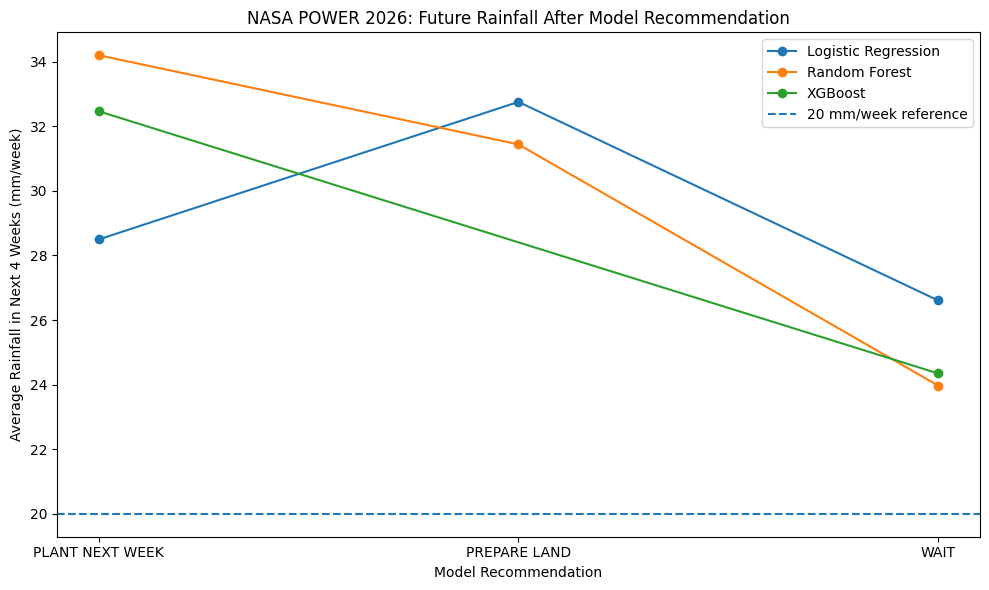


Plot saved:
/content/drive/MyDrive/nasa_power_2026_next_4_weeks_check/next_4_weeks_average_rainfall_by_recommendation.png


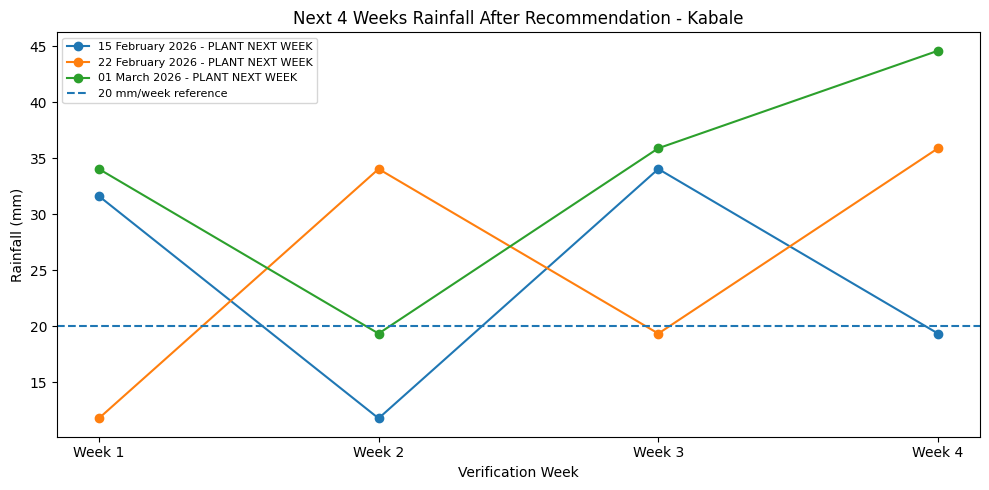

Saved plot for Kabale:
/content/drive/MyDrive/nasa_power_2026_next_4_weeks_check/selected_examples_next_4_weeks_rainfall_Kabale.png


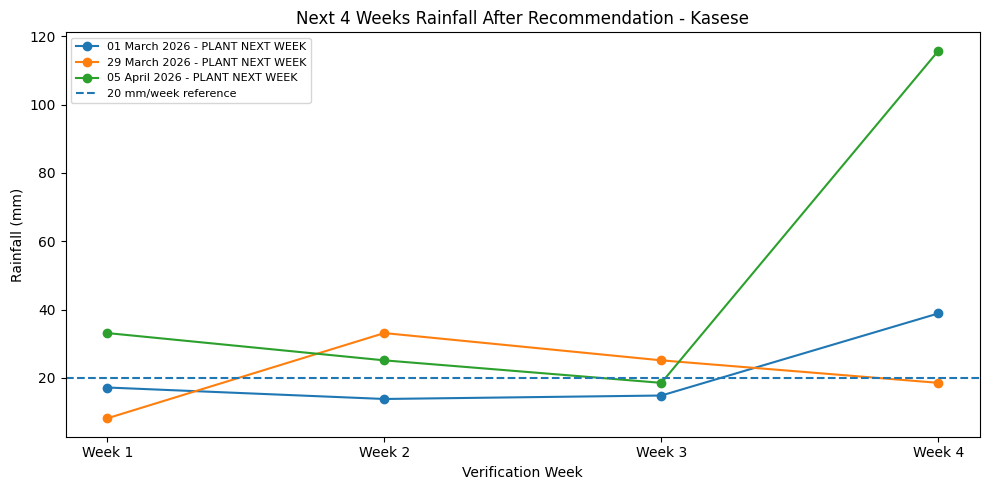

Saved plot for Kasese:
/content/drive/MyDrive/nasa_power_2026_next_4_weeks_check/selected_examples_next_4_weeks_rainfall_Kasese.png


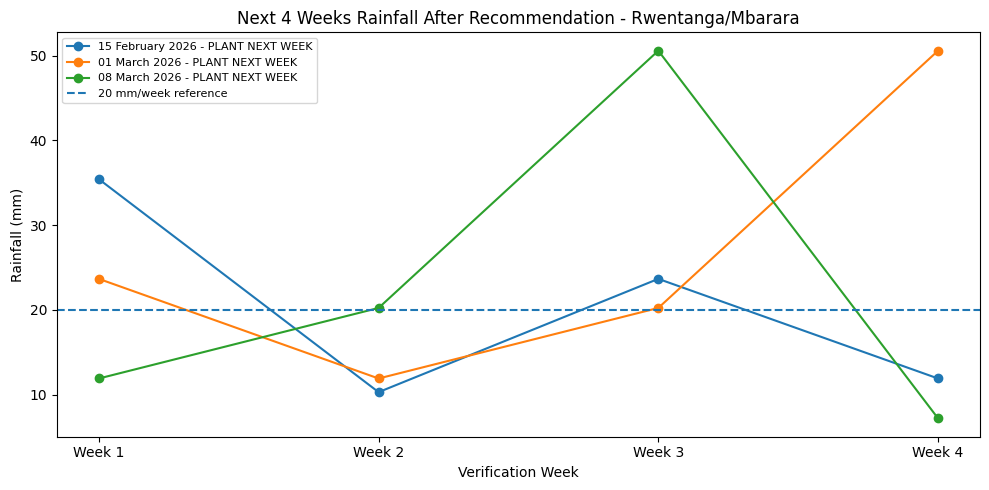

Saved plot for Rwentanga/Mbarara:
/content/drive/MyDrive/nasa_power_2026_next_4_weeks_check/selected_examples_next_4_weeks_rainfall_Rwentanga_Mbarara.png

PROCESS COMPLETED SUCCESSFULLY
The model made recommendations first.
The recommendations were not changed.
The next 4 weeks of NASA POWER rainfall were checked after prediction.
All outputs were saved in:
/content/drive/MyDrive/nasa_power_2026_next_4_weeks_check


In [ ]:
# ============================================================
# NASA POWER 2026 EXTERNAL VERIFICATION
# Model recommends first, then code checks NEXT 4 WEEKS rainfall
# Recommendation is NOT changed after verification
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

# ------------------------------------------------------------
# STEP 1: MOUNT GOOGLE DRIVE
# ------------------------------------------------------------

drive.mount("/content/drive")

# ------------------------------------------------------------
# STEP 2: CONFIGURATION
# ------------------------------------------------------------


NASA_FILES = {
    "Rwentanga/Mbarara": "/content/drive/MyDrive/rwentanga_area.csv",
    "Kabale": "/content/drive/MyDrive/kabale_area.csv",
    "Kasese": "/content/drive/MyDrive/kasese.csv"
}

# Saved model files from  trained planting advisory model.

ALL_MODELS_PATH = "/content/drive/MyDrive/planting_models_all_leakage_safe.pkl"
SCALER_PATH = "/content/drive/MyDrive/planting_advisory_scaler_leakage_safe.pkl"
FEATURES_PATH = "/content/drive/MyDrive/planting_advisory_features_leakage_safe.json"

# Output folder
OUTPUT_FOLDER = "/content/drive/MyDrive/nasa_power_2026_next_4_weeks_check"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Model to use for selecting 3 examples per location
EXAMPLE_MODEL = "XGBoost"

# ------------------------------------------------------------
# STEP 3: LOAD TRAINED MODELS, SCALER, AND FEATURE LIST
# ------------------------------------------------------------

models = joblib.load(ALL_MODELS_PATH)
scaler = joblib.load(SCALER_PATH)

with open(FEATURES_PATH, "r") as f:
    model_features = json.load(f)

print("Loaded models:")
for name in models.keys():
    print("-", name)

print("\nModel features used:")
print(model_features)

# ------------------------------------------------------------
# STEP 4: READ NASA POWER CSV
# ------------------------------------------------------------

def read_nasa_power_csv(file_path, location_name):
    """
    Reads NASA POWER CSV file.

    Expected NASA POWER variables:
    YEAR
    DOY
    T2M
    PRECTOTCORR

    T2M = daily 2-metre temperature
    PRECTOTCORR = daily corrected precipitation
    """

    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    start_row = None

    for i, line in enumerate(lines):
        if line.strip().startswith("YEAR,DOY"):
            start_row = i
            break

    if start_row is None:
        raise ValueError(f"Could not find data header YEAR,DOY in {file_path}")

    df = pd.read_csv(file_path, skiprows=start_row)
    df.columns = [col.strip() for col in df.columns]

    required_cols = ["YEAR", "DOY", "T2M", "PRECTOTCORR"]

    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {file_path}: {missing}")

    # Replace NASA missing value code
    df = df.replace(-999, np.nan)

    # Keep valid rows
    df = df.dropna(subset=required_cols)

    # Create date from YEAR and DOY
    df["date"] = (
        pd.to_datetime(df["YEAR"].astype(int).astype(str), format="%Y")
        + pd.to_timedelta(df["DOY"].astype(int) - 1, unit="D")
    )

    df["location"] = location_name

    # Rename to simpler names
    df = df.rename(columns={
        "T2M": "daily_t2m",
        "PRECTOTCORR": "daily_rain"
    })

    return df[["location", "date", "daily_t2m", "daily_rain"]]

# ------------------------------------------------------------
# STEP 5: CONVERT DAILY NASA POWER DATA TO WEEKLY DATA
# ------------------------------------------------------------

def daily_to_weekly(df_daily):
    """
    Converts daily NASA POWER data to weekly data.

    Weekly rainfall = sum of daily rainfall in that week.
    Weekly temperature = average daily temperature in that week.
    """

    df_daily = df_daily.copy()
    df_daily["date"] = pd.to_datetime(df_daily["date"])

    weekly = (
        df_daily
        .set_index("date")
        .groupby("location")
        .resample("1W")
        .agg({
            "daily_rain": "sum",
            "daily_t2m": "mean"
        })
        .reset_index()
    )

    weekly = weekly.rename(columns={
        "date": "time",
        "daily_rain": "tp",
        "daily_t2m": "t2m"
    })

    weekly["time"] = pd.to_datetime(weekly["time"])
    weekly["year"] = weekly["time"].dt.year
    weekly["week_of_year"] = weekly["time"].dt.isocalendar().week.astype(int)

    return weekly

# ------------------------------------------------------------
# STEP 6: CREATE MODEL FEATURES
# ------------------------------------------------------------

def create_model_features(df):
    """
    Creates the same features used during model training.

    These features are used for prediction:
    t2m
    rain_lag1
    rain_lag2
    temp_lag1
    rain_trend
    rain_acceleration
    sin_week
    cos_week
    """

    df = df.copy()
    df = df.sort_values(["location", "time"]).reset_index(drop=True)

    group_cols = ["location"]

    # Lag features
    df["rain_lag1"] = df.groupby(group_cols)["tp"].shift(1)
    df["rain_lag2"] = df.groupby(group_cols)["tp"].shift(2)
    df["temp_lag1"] = df.groupby(group_cols)["t2m"].shift(1)

    # Rainfall trend
    df["rain_trend"] = df["rain_lag1"] - df["rain_lag2"]

    # Rainfall acceleration
    df["rain_acceleration"] = (
        df["tp"] - 2 * df["rain_lag1"] + df["rain_lag2"]
    )

    # Seasonal encoding
    df["sin_week"] = np.sin(2 * np.pi * df["week_of_year"] / 52)
    df["cos_week"] = np.cos(2 * np.pi * df["week_of_year"] / 52)

    return df

# ------------------------------------------------------------
# STEP 7: ADD NEXT 4 WEEKS RAINFALL VERIFICATION INFORMATION
# ------------------------------------------------------------

def add_next_4_weeks_rainfall_check(df):
    """
    Adds future rainfall information for verification only.

    Important:
    These future rainfall values are NOT used to make predictions.
    They are only used after the model has made a recommendation.
    """

    df = df.copy()
    df = df.sort_values(["location", "time"]).reset_index(drop=True)

    group_cols = ["location"]

    # Future weekly rainfall
    df["rain_week_1_after"] = df.groupby(group_cols)["tp"].shift(-1)
    df["rain_week_2_after"] = df.groupby(group_cols)["tp"].shift(-2)
    df["rain_week_3_after"] = df.groupby(group_cols)["tp"].shift(-3)
    df["rain_week_4_after"] = df.groupby(group_cols)["tp"].shift(-4)

    # Future week dates
    df["date_week_1_after"] = df.groupby(group_cols)["time"].shift(-1)
    df["date_week_2_after"] = df.groupby(group_cols)["time"].shift(-2)
    df["date_week_3_after"] = df.groupby(group_cols)["time"].shift(-3)
    df["date_week_4_after"] = df.groupby(group_cols)["time"].shift(-4)

    # Future week numbers
    df["week_1_after_number"] = pd.to_datetime(df["date_week_1_after"]).dt.isocalendar().week.astype("Int64")
    df["week_2_after_number"] = pd.to_datetime(df["date_week_2_after"]).dt.isocalendar().week.astype("Int64")
    df["week_3_after_number"] = pd.to_datetime(df["date_week_3_after"]).dt.isocalendar().week.astype("Int64")
    df["week_4_after_number"] = pd.to_datetime(df["date_week_4_after"]).dt.isocalendar().week.astype("Int64")

    # Future month names
    df["month_1_after"] = pd.to_datetime(df["date_week_1_after"]).dt.month_name()
    df["month_2_after"] = pd.to_datetime(df["date_week_2_after"]).dt.month_name()
    df["month_3_after"] = pd.to_datetime(df["date_week_3_after"]).dt.month_name()
    df["month_4_after"] = pd.to_datetime(df["date_week_4_after"]).dt.month_name()

    # Total and average rainfall in next 4 weeks
    df["next_4_weeks_total_rainfall"] = (
        df["rain_week_1_after"]
        + df["rain_week_2_after"]
        + df["rain_week_3_after"]
        + df["rain_week_4_after"]
    )

    df["next_4_weeks_average_rainfall"] = (
        df["next_4_weeks_total_rainfall"] / 4
    )

    # Prediction week labels
    df["prediction_week_number"] = df["time"].dt.isocalendar().week.astype(int)
    df["prediction_month"] = df["time"].dt.month_name()
    df["prediction_date"] = df["time"].dt.strftime("%d %B %Y")

    # Human-readable verification period
    df["verification_period"] = (
        "Week "
        + df["week_1_after_number"].astype(str)
        + " ("
        + df["month_1_after"].astype(str)
        + ") to Week "
        + df["week_4_after_number"].astype(str)
        + " ("
        + df["month_4_after"].astype(str)
        + ")"
    )

    return df

# ------------------------------------------------------------
# STEP 8: MODEL CLASS TO FARMER RECOMMENDATION
# ------------------------------------------------------------

def class_to_recommendation(pred_class):
    """
    Converts model class into farmer-friendly recommendation.
    """

    pred_class = int(pred_class)

    if pred_class == 0:
        return "WAIT"
    elif pred_class == 1:
        return "PREPARE LAND"
    elif pred_class == 2:
        return "PLANT NEXT WEEK"
    else:
        return "UNKNOWN"

# ------------------------------------------------------------
# STEP 9: VERIFY RECOMMENDATION USING NEXT 4 WEEKS AVERAGE RAINFALL
# ------------------------------------------------------------

def verify_using_next_4_week_average(recommendation, avg_rain_4weeks):
    """
    This function does NOT change the recommendation.

    It only checks whether the next 4 weeks of rainfall support
    the recommendation that was already made by the model.
    """

    if pd.isna(avg_rain_4weeks):
        return "Not enough future rainfall data"

    if recommendation == "PLANT NEXT WEEK":
        if avg_rain_4weeks >= 20:
            return "Supported by next 4 weeks rainfall"
        elif avg_rain_4weeks >= 15:
            return "Partially supported"
        else:
            return "Not supported by next 4 weeks rainfall"

    elif recommendation == "PREPARE LAND":
        if avg_rain_4weeks >= 15:
            return "Supported by improving rainfall"
        elif avg_rain_4weeks >= 10:
            return "Partially supported"
        else:
            return "Not supported by next 4 weeks rainfall"

    elif recommendation == "WAIT":
        if avg_rain_4weeks < 15:
            return "Supported by low rainfall"
        else:
            return "Rainfall later improved"

    else:
        return "Unknown"

# ------------------------------------------------------------
# STEP 10: LOAD ALL NASA POWER DAILY FILES
# ------------------------------------------------------------

all_daily = []

for location_name, file_path in NASA_FILES.items():
    print(f"\nReading NASA POWER data for {location_name}")

    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"File not found: {file_path}. "
            "Please upload it to Google Drive or update the path."
        )

    df_location = read_nasa_power_csv(file_path, location_name)
    all_daily.append(df_location)

daily_df = pd.concat(all_daily, ignore_index=True)

print("\nDaily NASA POWER data loaded successfully.")
print("Daily data shape:", daily_df.shape)
print(daily_df.head())

# Save daily combined dataset
daily_output_path = os.path.join(OUTPUT_FOLDER, "nasa_power_2026_daily_combined.csv")
daily_df.to_csv(daily_output_path, index=False)

print("\nSaved combined daily dataset:")
print(daily_output_path)

# ------------------------------------------------------------
# STEP 11: PREPARE WEEKLY DATA
# ------------------------------------------------------------

weekly_df = daily_to_weekly(daily_df)
weekly_df = create_model_features(weekly_df)
weekly_df = add_next_4_weeks_rainfall_check(weekly_df)

# Keep only rows where:
# 1. model features exist
# 2. next 4 weeks rainfall exists for verification
test_df = weekly_df.dropna(
    subset=model_features + ["next_4_weeks_average_rainfall"]
).reset_index(drop=True)

print("\nWeekly NASA POWER data prepared.")
print("Weekly data shape:", test_df.shape)
print(test_df.head())

weekly_output_path = os.path.join(OUTPUT_FOLDER, "nasa_power_2026_weekly_prepared.csv")
test_df.to_csv(weekly_output_path, index=False)

print("\nSaved prepared weekly dataset:")
print(weekly_output_path)

# ------------------------------------------------------------
# STEP 12: MAKE RECOMMENDATIONS FIRST, THEN VERIFY NEXT 4 WEEKS
# ------------------------------------------------------------

X = test_df[model_features].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

X_scaled = scaler.transform(X)

all_results = []

for model_name, model in models.items():

    print("\n==================================================")
    print(f"MODEL: {model_name}")
    print("==================================================")

    preds = model.predict(X_scaled)

    result_df = test_df.copy()

    result_df["model"] = model_name
    result_df["predicted_class"] = preds
    result_df["recommendation"] = result_df["predicted_class"].apply(
        class_to_recommendation
    )

    # Get probabilities if the model supports predict_proba
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_scaled)

        # Assumes 3 classes: 0, 1, 2
        result_df["prob_not_ready"] = probs[:, 0]
        result_df["prob_prepare_land"] = probs[:, 1]
        result_df["prob_planting_window"] = probs[:, 2]
    else:
        result_df["prob_not_ready"] = np.nan
        result_df["prob_prepare_land"] = np.nan
        result_df["prob_planting_window"] = np.nan

    # Verification happens after recommendation.
    # Recommendation remains unchanged.
    result_df["next_4_week_check"] = result_df.apply(
        lambda row: verify_using_next_4_week_average(
            row["recommendation"],
            row["next_4_weeks_average_rainfall"]
        ),
        axis=1
    )

    print("\nRecommendation counts:")
    print(result_df["recommendation"].value_counts())

    print("\nNext 4 weeks verification counts:")
    print(result_df["next_4_week_check"].value_counts())

    display_cols = [
        "location",
        "prediction_date",
        "prediction_week_number",
        "prediction_month",
        "tp",
        "t2m",
        "recommendation",
        "verification_period",
        "rain_week_1_after",
        "rain_week_2_after",
        "rain_week_3_after",
        "rain_week_4_after",
        "next_4_weeks_average_rainfall",
        "next_4_week_check"
    ]

    print("\nSample output with exact verification weeks:")
    print(result_df[display_cols].head(15))

    save_path = os.path.join(
        OUTPUT_FOLDER,
        f"nasa_2026_next_4_weeks_check_{model_name.replace(' ', '_')}.csv"
    )

    result_df.to_csv(save_path, index=False)

    print("\nSaved model verification file:")
    print(save_path)

    all_results.append(result_df)

# ------------------------------------------------------------
# STEP 13: COMBINE ALL MODEL RESULTS
# ------------------------------------------------------------

combined_results = pd.concat(all_results, ignore_index=True)

combined_path = os.path.join(
    OUTPUT_FOLDER,
    "nasa_2026_all_models_next_4_weeks_check.csv"
)

combined_results.to_csv(combined_path, index=False)

print("\nCombined all-model results saved:")
print(combined_path)

# ------------------------------------------------------------
# STEP 14: CREATE SUMMARY TABLE
# ------------------------------------------------------------

summary = (
    combined_results
    .groupby(["model", "recommendation", "next_4_week_check"])
    .size()
    .reset_index(name="count")
)

summary_path = os.path.join(
    OUTPUT_FOLDER,
    "nasa_2026_next_4_weeks_summary.csv"
)

summary.to_csv(summary_path, index=False)

print("\nSummary table:")
print(summary)
print("\nSaved summary table:")
print(summary_path)

# ------------------------------------------------------------
# STEP 15: LOCATION-LEVEL SUMMARY
# ------------------------------------------------------------

location_summary = (
    combined_results
    .groupby(["model", "location", "recommendation", "next_4_week_check"])
    .size()
    .reset_index(name="count")
)

location_summary_path = os.path.join(
    OUTPUT_FOLDER,
    "nasa_2026_location_level_summary.csv"
)

location_summary.to_csv(location_summary_path, index=False)

print("\nLocation-level summary saved:")
print(location_summary_path)

# ------------------------------------------------------------
# STEP 16: SELECT 3 VERIFICATION EXAMPLES PER LOCATION
# ------------------------------------------------------------

if EXAMPLE_MODEL not in combined_results["model"].unique():
    print(f"\nWARNING: {EXAMPLE_MODEL} not found. Using first available model instead.")
    EXAMPLE_MODEL = combined_results["model"].unique()[0]

examples_df = combined_results[combined_results["model"] == EXAMPLE_MODEL].copy()

# Rank verification statuses so useful examples appear first
status_order = {
    "Supported by next 4 weeks rainfall": 1,
    "Supported by improving rainfall": 1,
    "Supported by low rainfall": 1,
    "Partially supported": 2,
    "Rainfall later improved": 2,
    "Not supported by next 4 weeks rainfall": 3,
    "Not enough future rainfall data": 4,
    "Unknown": 5
}

examples_df["status_rank"] = (
    examples_df["next_4_week_check"]
    .map(status_order)
    .fillna(5)
)

selected_examples = (
    examples_df
    .sort_values(["location", "status_rank", "time"])
    .groupby("location")
    .head(3)
    .reset_index(drop=True)
)

selected_cols = [
    "location",
    "prediction_date",
    "prediction_week_number",
    "prediction_month",
    "tp",
    "t2m",
    "rain_lag1",
    "rain_lag2",
    "rain_trend",
    "rain_acceleration",
    "recommendation",
    "prob_not_ready",
    "prob_prepare_land",
    "prob_planting_window",
    "verification_period",
    "rain_week_1_after",
    "rain_week_2_after",
    "rain_week_3_after",
    "rain_week_4_after",
    "next_4_weeks_average_rainfall",
    "next_4_week_check"
]

selected_examples_output = selected_examples[selected_cols]

print("\n==================================================")
print(f"SELECTED 3 VERIFICATION EXAMPLES PER LOCATION - {EXAMPLE_MODEL}")
print("==================================================")
print(selected_examples_output)

examples_path = os.path.join(
    OUTPUT_FOLDER,
    f"selected_3_verification_examples_per_location_{EXAMPLE_MODEL}.csv"
)

selected_examples_output.to_csv(examples_path, index=False)

print("\nSelected examples saved:")
print(examples_path)

# ------------------------------------------------------------
# STEP 17: SAVE A CLEAN PRESENTATION TABLE
# ------------------------------------------------------------

presentation_table = selected_examples_output.copy()

presentation_table = presentation_table.rename(columns={
    "location": "Location",
    "prediction_date": "Prediction Date",
    "prediction_week_number": "Prediction Week",
    "prediction_month": "Prediction Month",
    "tp": "Current Week Rainfall (mm)",
    "t2m": "Current Temperature (C)",
    "recommendation": "Model Recommendation",
    "verification_period": "Verification Period",
    "rain_week_1_after": "Rainfall Week 1 After (mm)",
    "rain_week_2_after": "Rainfall Week 2 After (mm)",
    "rain_week_3_after": "Rainfall Week 3 After (mm)",
    "rain_week_4_after": "Rainfall Week 4 After (mm)",
    "next_4_weeks_average_rainfall": "Average Rainfall Next 4 Weeks (mm/week)",
    "next_4_week_check": "Verification Result"
})

presentation_path = os.path.join(
    OUTPUT_FOLDER,
    f"presentation_ready_3_examples_per_location_{EXAMPLE_MODEL}.csv"
)

presentation_table.to_csv(presentation_path, index=False)

print("\nPresentation-ready table saved:")
print(presentation_path)

# ------------------------------------------------------------
# STEP 18: PLOT AVERAGE NEXT 4-WEEK RAINFALL BY RECOMMENDATION
# ------------------------------------------------------------

plot_data = (
    combined_results
    .groupby(["model", "recommendation"])["next_4_weeks_average_rainfall"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for model_name in plot_data["model"].unique():
    temp = plot_data[plot_data["model"] == model_name]

    plt.plot(
        temp["recommendation"],
        temp["next_4_weeks_average_rainfall"],
        marker="o",
        label=model_name
    )

plt.axhline(
    20,
    linestyle="--",
    label="20 mm/week reference"
)

plt.ylabel("Average Rainfall in Next 4 Weeks (mm/week)")
plt.xlabel("Model Recommendation")
plt.title("NASA POWER 2026: Future Rainfall After Model Recommendation")
plt.legend()
plt.tight_layout()

plot_path = os.path.join(
    OUTPUT_FOLDER,
    "next_4_weeks_average_rainfall_by_recommendation.png"
)

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nPlot saved:")
print(plot_path)

# ------------------------------------------------------------
# STEP 19: PLOT SELECTED EXAMPLES
# ------------------------------------------------------------

for location in selected_examples_output["location"].unique():

    loc_df = selected_examples_output[
        selected_examples_output["location"] == location
    ].copy()

    plt.figure(figsize=(10, 5))

    for idx, row in loc_df.iterrows():
        label = f"{row['prediction_date']} - {row['recommendation']}"

        rainfall_values = [
            row["rain_week_1_after"],
            row["rain_week_2_after"],
            row["rain_week_3_after"],
            row["rain_week_4_after"]
        ]

        plt.plot(
            ["Week 1", "Week 2", "Week 3", "Week 4"],
            rainfall_values,
            marker="o",
            label=label
        )

    plt.axhline(20, linestyle="--", label="20 mm/week reference")
    plt.title(f"Next 4 Weeks Rainfall After Recommendation - {location}")
    plt.xlabel("Verification Week")
    plt.ylabel("Rainfall (mm)")
    plt.legend(fontsize=8)
    plt.tight_layout()

    safe_location = location.replace("/", "_").replace(" ", "_")

    loc_plot_path = os.path.join(
        OUTPUT_FOLDER,
        f"selected_examples_next_4_weeks_rainfall_{safe_location}.png"
    )

    plt.savefig(loc_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved plot for {location}:")
    print(loc_plot_path)

# ------------------------------------------------------------
# STEP 20: FINAL MESSAGE
# ------------------------------------------------------------

print("\n==================================================")
print("PROCESS COMPLETED SUCCESSFULLY")
print("==================================================")
print("The model made recommendations first.")
print("The recommendations were not changed.")
print("The next 4 weeks of NASA POWER rainfall were checked after prediction.")
print("All outputs were saved in:")
print(OUTPUT_FOLDER)